In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import poisson
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
from scipy.optimize import curve_fit

In [2]:
data=pd.read_csv('Tables/Gentamicin.csv')
#data=pd.read_csv('Tables/Ciprofloxacin.csv')
#data=pd.read_csv('Tables/Chloramphenicol.csv')
#data=pd.read_csv('Tables/Tetracycline.csv')

In [3]:
qzero_threshold=0.6
data.drop(data[data['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)

# Single fit

In [4]:
y=data['q_chip_like'].values
c=data['concentration'].values
popt, pcov = curve_fit(lambda t, qz,a,b: 1- (1-qz)* np.exp(-np.power(t/a,b)), c,y,bounds=([0,0,0],[1,np.inf,np.inf]),p0=[0.3,66,3])

In [5]:
popt, pcov

(array([0.24056739, 0.56879807, 5.37729684]),
 array([[ 2.86350079e-04,  4.86233318e-05,  2.66902492e-03],
        [ 4.86233318e-05,  7.59096579e-05, -6.15586476e-04],
        [ 2.66902492e-03, -6.15586476e-04,  4.09770227e-01]]))

(0.0, 2.0)

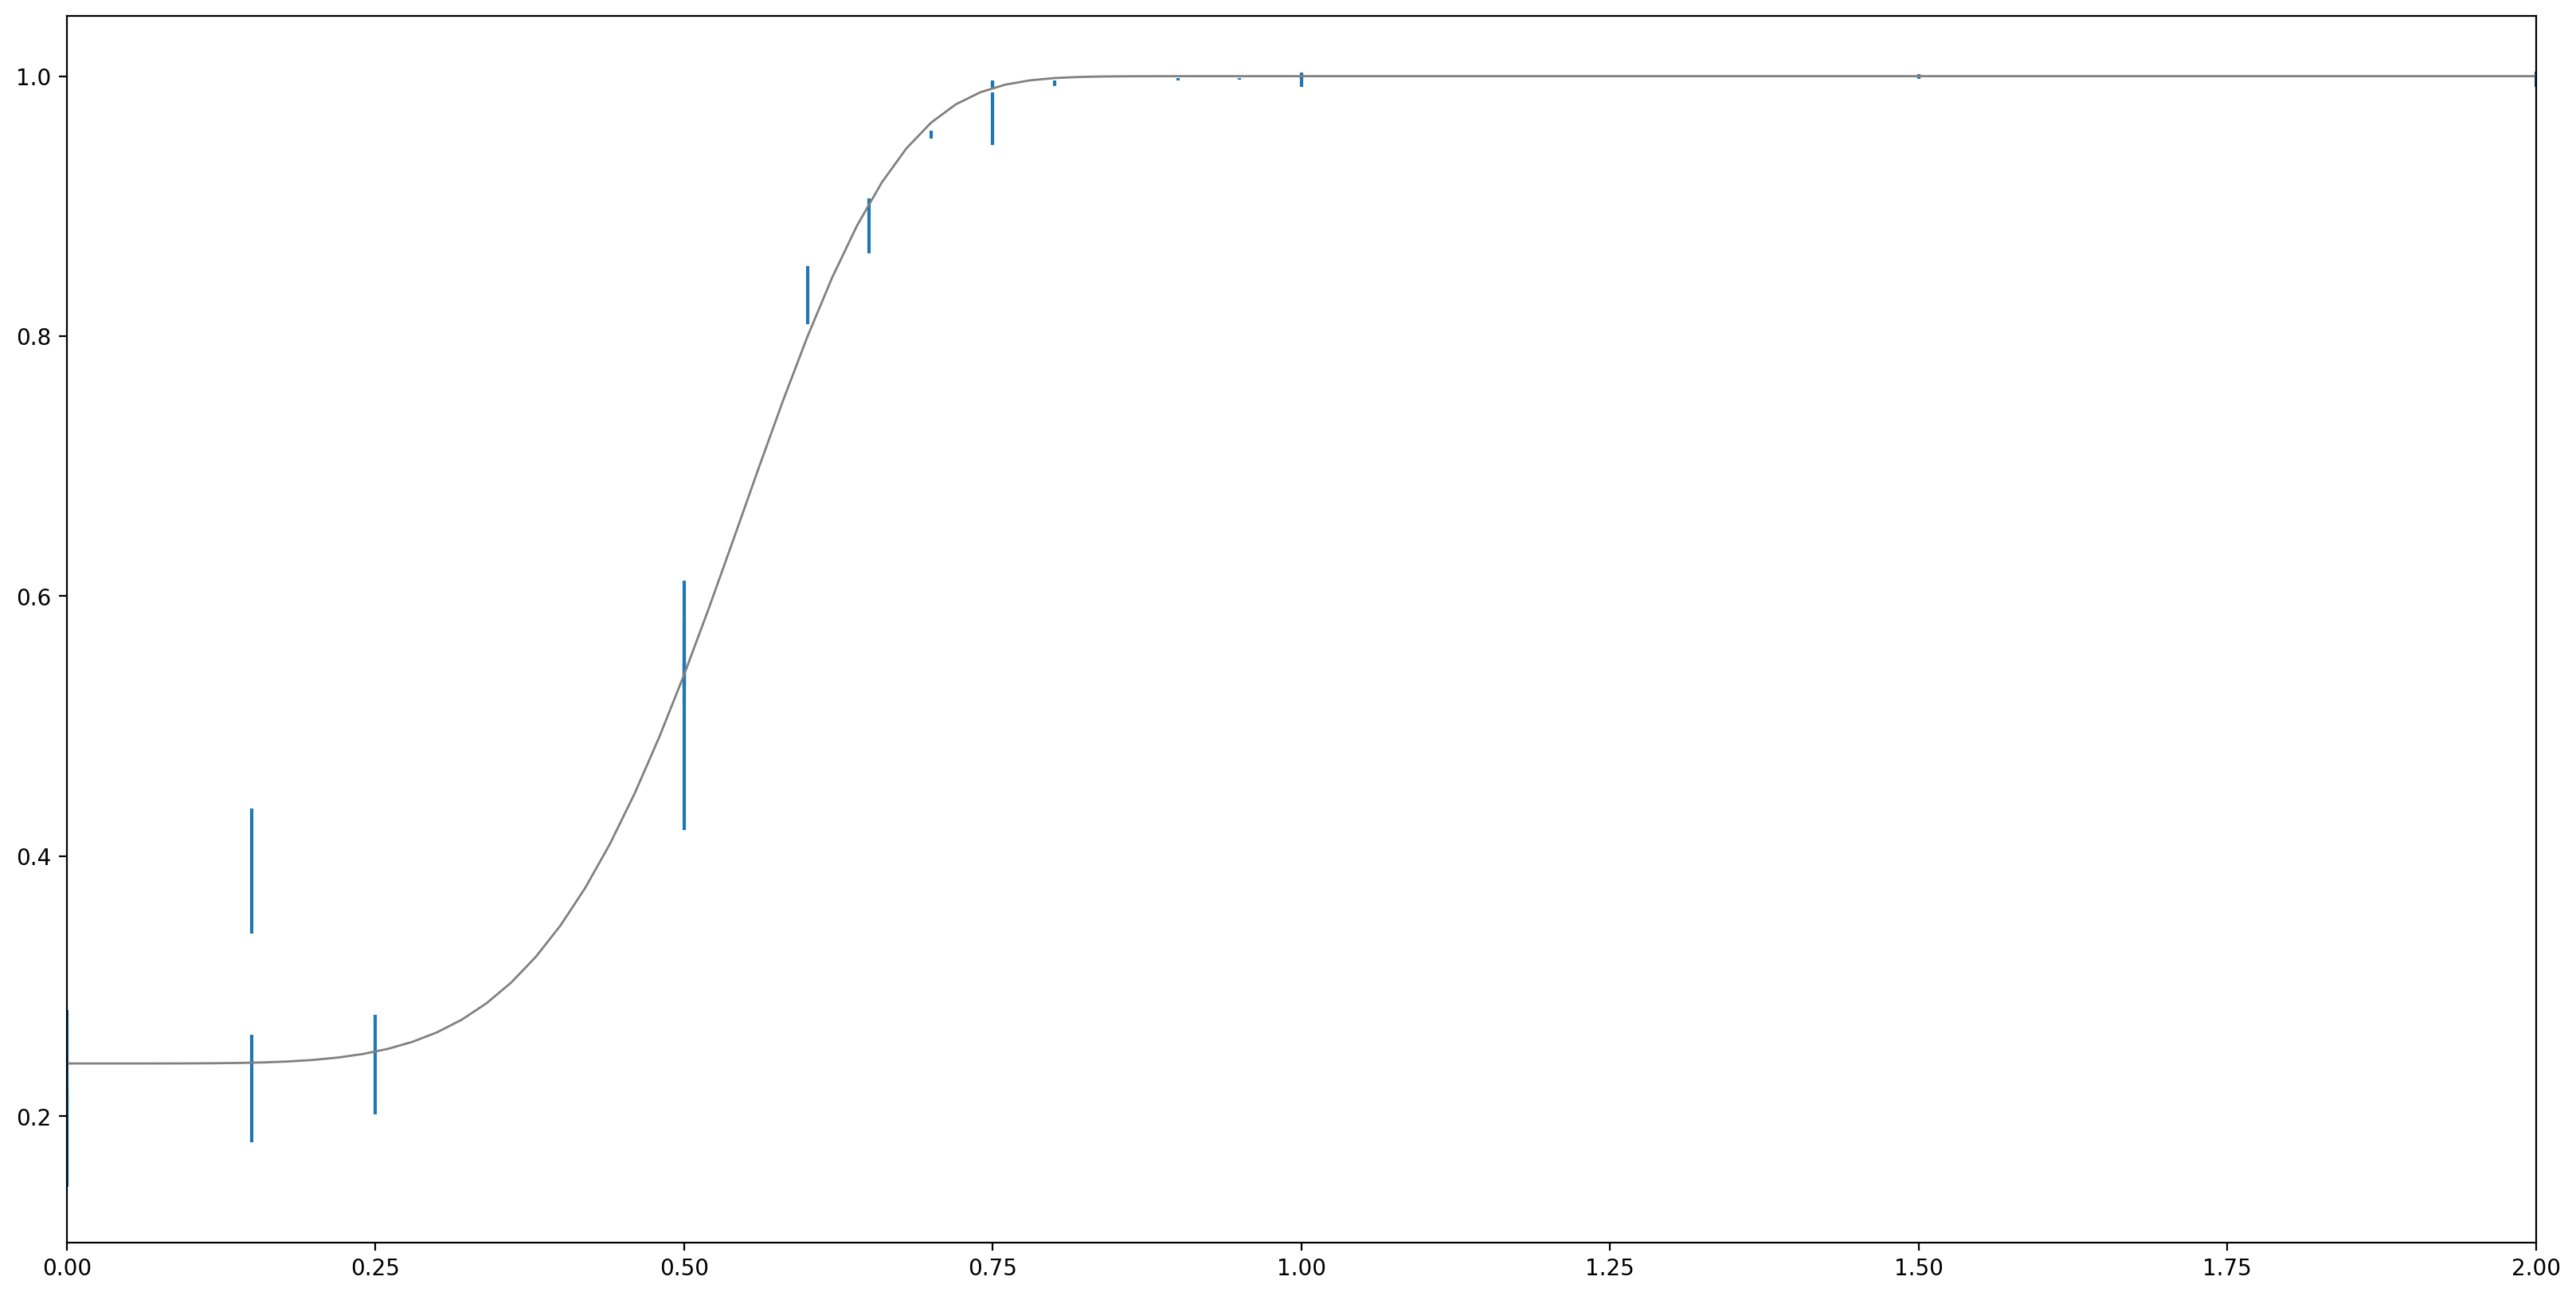

In [6]:
xmax=2
x_fitted = np.linspace(0, 100, 5000)
color=sns.color_palette("colorblind")

z=1


fig = plt.figure(figsize=(20, 10), dpi=200)


plt.errorbar(c,y,z* np.sqrt(data['var_q_chip_like'].values),linestyle='')

y_fitted=1-(1-popt[0]) * np.exp(-np.power(x_fitted/popt[1],popt[2]))
plt.plot(x_fitted, y_fitted,linewidth=1,color='gray')

plt.xlim([0,xmax])

In [4]:
df=pd.DataFrame(np.insert(pcov, 0,popt, axis=0))
df=df.rename(columns={0:'q_0',1:'a',2:'b'})

In [4]:
# warning overwrites provided table,  adapt to antibiotic used
df.to_csv(f'Tables/Chloramphenicol_Fit.csv') 
#df.to_csv(f'Tables/Ciprofloxacin_Fit.csv') 
#df.to_csv(f'Tables/Gentamicin_Fit.csv') 

NameError: name 'data' is not defined

# Two fits for Tetra


In [16]:
y=data.loc[data.date==20230404,'q_chip_like'].values
c=data.loc[data.date==20230404,'concentration'].values
popt, pcov = curve_fit(lambda t, qz,a,b: 1- (1-qz)* np.exp(-np.power(t/a,b)), c,y,bounds=([0,0,0],[1,np.inf,np.inf]),p0=[0.3,66,3])

y2=data.loc[data.date==20230315,'q_chip_like'].values
c2=data.loc[data.date==20230315,'concentration'].values


popt2, pcov2 = curve_fit(lambda t, qz,a,b: 1- (1-qz)* np.exp(-np.power(t/a,b)), c2,y2,bounds=([0,0,0],[1,np.inf,np.inf]),p0=[0.3,66,3])

In [17]:
popt, pcov

(array([ 0.2844547 , 28.52204124,  1.93151905]),
 array([[4.18313554e-04, 1.31966303e-02, 1.87135000e-03],
        [1.31966303e-02, 1.37765930e+00, 5.55986086e-02],
        [1.87135000e-03, 5.55986086e-02, 2.87678130e-02]]))

In [18]:
popt2, pcov2 

(array([ 0.28545243, 65.91364627,  2.87808724]),
 array([[1.78148914e-04, 7.37097990e-03, 1.10371772e-03],
        [7.37097990e-03, 3.39217436e-01, 4.51571257e-02],
        [1.10371772e-03, 4.51571257e-02, 7.94386598e-03]]))

(0.0, 100.0)

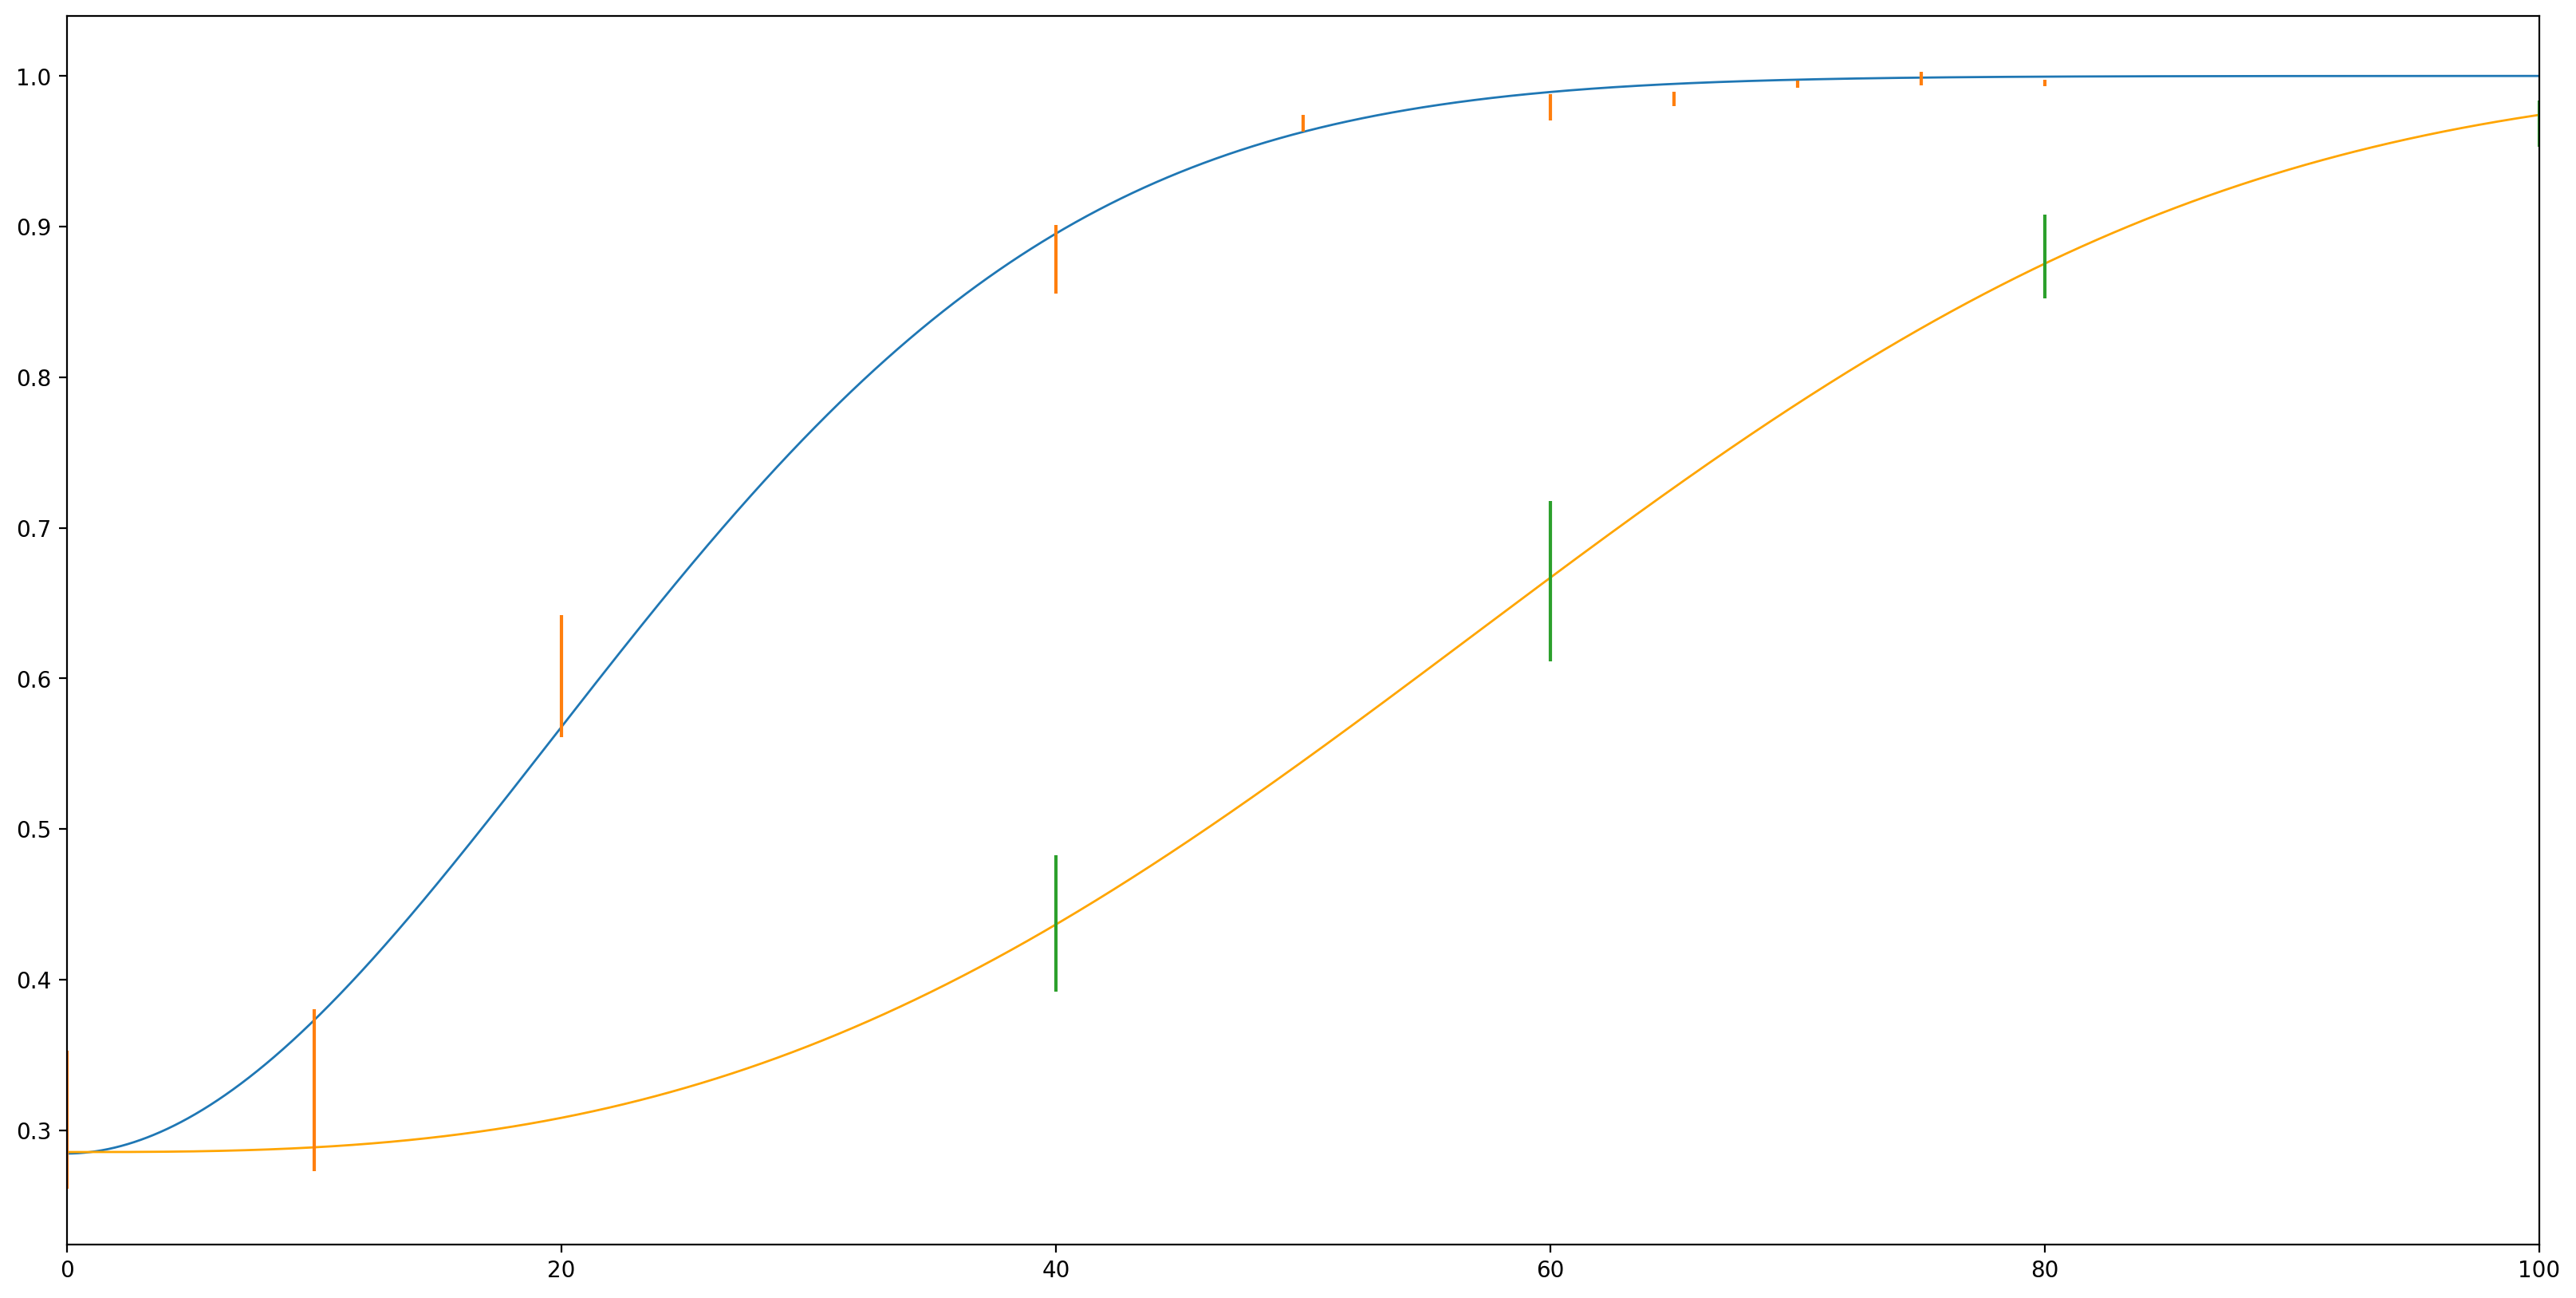

In [20]:
xmax=100
x_fitted = np.linspace(0, 100, 5000)
color=sns.color_palette("colorblind")

z=1
markers=['o','s','<','v','h','P','*','^','8','p','H','d','D','X']


fig = plt.figure(figsize=(20, 10), dpi=200)


y_fitted=1-(1-popt[0]) * np.exp(-np.power(x_fitted/popt[1],popt[2]))
plt.plot(x_fitted, y_fitted,linewidth=1)


y_fitted_2=1-(1-popt2[0]) * np.exp(-np.power(x_fitted/popt2[1],popt2[2]))
plt.plot(x_fitted, y_fitted_2, 'orange',linewidth=1)

plt.errorbar(c,y,z* np.sqrt(data.loc[data.date==20230404,'var_q_chip_like'].values),linestyle='')
plt.errorbar(c2,y2,z* np.sqrt(data.loc[data.date==20230315,'var_q_chip_like'].values),linestyle='')

plt.xlim([0,xmax])

In [21]:
df=pd.DataFrame(np.insert(pcov, 0,popt, axis=0))
df=df.rename(columns={0:'q_0',1:'a',2:'b'})

In [22]:
df2=pd.DataFrame(np.insert(pcov2, 0,popt2, axis=0))
df2=df2.rename(columns={0:'q_0',1:'a',2:'b'})

In [23]:
dg=pd.concat([df,df2])

In [24]:
dg

,q_0,a,b
0,0.284455,28.522041,1.931519
1,0.000418,0.013197,0.001871
2,0.013197,1.377659,0.055599
3,0.001871,0.055599,0.028768
0,0.285452,65.913646,2.878087
1,0.000178,0.007371,0.001104
2,0.007371,0.339217,0.045157
3,0.001104,0.045157,0.007944


In [135]:
# warning overwrites provided table,  adapt to antibiotic used

dg.to_csv(f'Tables/Tetracycline_Fit.csv') 


,0,1,2
0,0.284455,28.522041,1.931519
1,0.000418,0.013197,0.001871
2,0.013197,1.377659,0.055599
3,0.001871,0.055599,0.028768
0,0.285452,65.913646,2.878087
1,0.000178,0.007371,0.001104
2,0.007371,0.339217,0.045157
3,0.001104,0.045157,0.007944
